In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loading the datasets in

In [2]:
mental_health = pd.read_csv('data/cleaned_mental_health_data.csv')
mental_health['year'] = pd.to_datetime(mental_health['Timestamp']).dt.year
mental_health = mental_health[mental_health['year'] == 2014]
music = pd.read_csv('data/music_data_with_country_info.csv')

Before our ACF and F-test, we need to test for normality for both the composite mental health score and music valence by plotting the quantiles of both against the normal distribution.

## Q-Q Plot for Composite Mental Health Score

In [3]:
import statsmodels.formula.api as smf

model = smf.ols("composite_mh_score ~ C(Season)", data=mental_health).fit()

In [4]:
residuals = model.resid

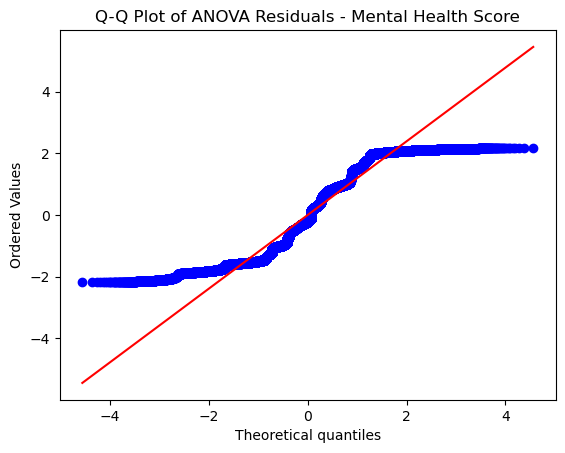

In [5]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals - Mental Health Score")
plt.show()

The S-curve indicates a platykurtic distribution: the data is more concentrated around the center with lighter tails than a true normal. This is a direct consequence of PCA producing a bounded composite score. For the F-test, we will need to interpret tail-end results cautiously.

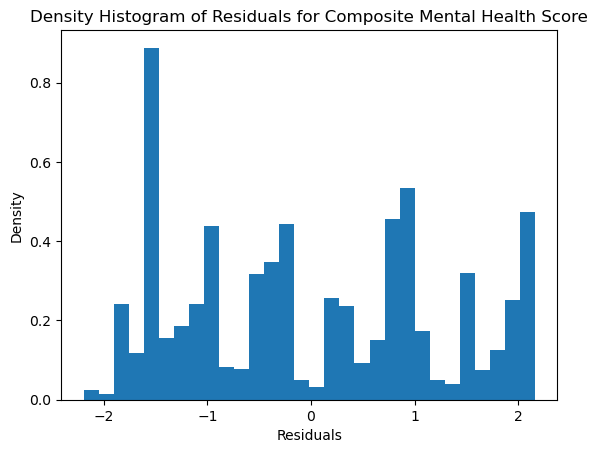

In [13]:
plt.hist(residuals, bins=30, density=True)
plt.title("Density Histogram of Residuals for Composite Mental Health Score")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

## Q-Q Plot for Music Valence

In [9]:
music.columns

Index(['twitter-id', 'user-id', 'month', 'weekday', 'longitude', 'latitude',
       'country-id', 'city-id', 'artist-id', 'track-id',
       ...
       'Instrument_-_Electric_Guitar_(distorted)-Solo',
       'Instrument_-_Female_Lead_Vocals-Solo', 'Instrument_-_Harmonica-Solo',
       'Instrument_-_Male_Lead_Vocals-Solo', 'Instrument_-_Piano-Solo',
       'Instrument_-_Saxophone-Solo', 'Instrument_-_Trumpet-Solo', 'season',
       'valence', 'country'],
      dtype='object', length=189)

In [10]:
model_valence = smf.ols("valence ~ C(season)", data=music).fit()
residuals_valence = model_valence.resid

Text(0.5, 1.0, 'Q-Q Plot of ANOVA Residuals - Music Valence')

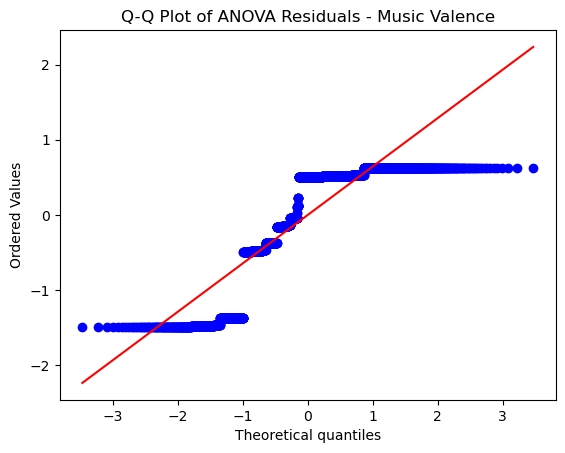

In [11]:
stats.probplot(residuals_valence, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals - Music Valence")

The step-like pattern with hard compression at ±1 reflects near-discrete clustering (tracks rated 0 or 1). This near-discrete clustering reinforces our use for Q-Q plots over the K-S test, which would have hidden the discrete structure (showing only a general deviation from the smooth normal CDF).

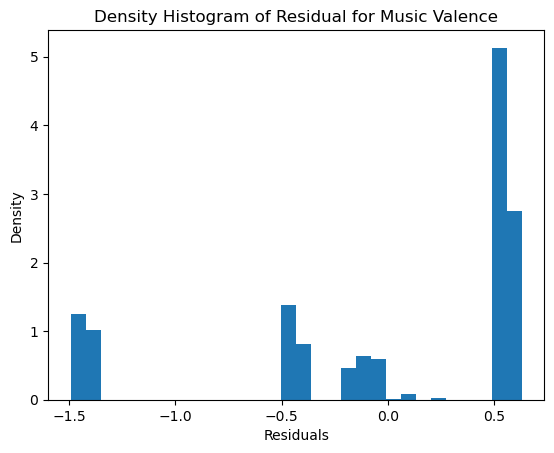

In [16]:
plt.hist(residuals_valence, bins=30, density=True)
plt.title("Density Histogram of Residual for Music Valence")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

The clustering distribution suggests that we may have to deviate from our originally pitched F-test, which requires normality. We would either have to add noise to our data to make the music valence more normal, or swtich to a different test that does not require normality like the Kruskal-Wallis test.